# Enrichments

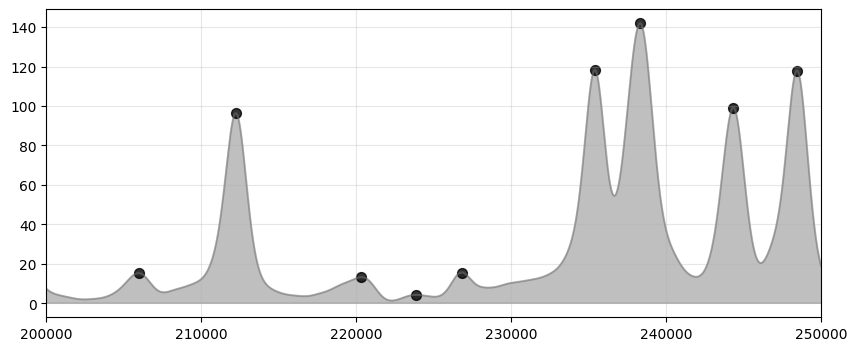

In [ ]:
# ── Imports ──────────────────────────────────────────────────────────────────

# Standard
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# Bio
import bioframe
from scipy.signal import find_peaks
from scipy.interpolate import interp1d
from scipy.ndimage import gaussian_filter1d
%matplotlib inline


# ── Global Values ──────────────────────────────────────────────────────────────────

# Chromosomes
CHROMS = [
    'chrI',
    'chrII',
    'chrIII',
    'chrIV',
    'chrV',
    'chrVI',
    'chrVII',
    'chrVIII',
    'chrIX',
    'chrX',
    'chrXI',
    'chrXII',
    'chrXIII',
    'chrXIV',
    'chrXV',
    'chrXVI'
]


# Nucleosomes :
DATA_NUC = "/home/nicolas/Documents/Workspace/nucleo/outputs/NUC"+"/mono.midpoint.bigwig"

# Cohesin :
DATA_COHE = "/home/nicolas/Documents/Workspace/nucleo/outputs/NUC"+"/GSM4577764_Mcd1p_WT.bigwig"


# ── Window ──────────────────────────────────────────────────────────────────

# Reading Data:
data = DATA_COHE

# Choosing the region of reads
chrom = 'chrII'
df1 = bioframe.read_bigwig(data, chrom)
xlims = [200_000, 250_000]


# ── Calculations ──────────────────────────────────────────────────────────────────

# Note that bins have different sizes, in this case I interploate but you may also rebin to the scale is meaningful for your simulations
pos= np.array(df1["start"])+ np.rint(df1["end"]/2-df1["start"]/2)
enrichment = df1['value'].values

# Regular grid (1 bp spacing here)
pos_uniform = np.arange(pos.min(), pos.max()+1)

# Interpolate
f = interp1d(pos, enrichment,
             kind='linear',
             bounds_error=False,
             fill_value='extrapolate')
enrichment_uniform = f(pos_uniform)

# Smoothing -> sigma is the smooting parameter
# Based on the biological value : typically, beatween each car there is between 10 and 20 kb
enrichment_smooth = gaussian_filter1d(enrichment_uniform, sigma=500)

# Finding Peaks using Scipy
# With a minimum height of min_h and a minimum distance of min_d between peaks
min_h = 1
min_d = 10
prominence = 0.050
peaks, _ = find_peaks(enrichment_smooth,height=min_h,distance=int(min_d),prominence=prominence)


# ── Plot ──────────────────────────────────────────────────────────────────

plt.figure(figsize=(10, 4))
plt.plot(pos_uniform,enrichment_smooth,color="gray",alpha=0.5)
plt.fill_between(pos_uniform,enrichment_smooth,color="gray",alpha=0.5)
plt.scatter(pos_uniform[peaks], enrichment_smooth[peaks], color="black", s=50, alpha=0.8)
plt.xlim(xlims)
plt.grid(True, which="both", alpha=0.30)
plt.show()

In [2]:
# ── Calculating File ──────────────────────────────────────────────────────────────────

# Create a dataframe with the peaks heights and positions
df_CARs = []
for chrom in CHROMS[:]:
    df1 = bioframe.read_bigwig(data, chrom)
    pos= np.array(df1["start"])+ np.rint(df1["end"]/2-df1["start"]/2)
    enrichment = df1['value'].values
    pos_uniform = np.arange(pos.min(), pos.max()+1)
    f = interp1d(pos, enrichment,
                 kind='linear',
                 bounds_error=False,
                 fill_value='extrapolate')
    enrichment_uniform = f(pos_uniform)
    enrichment_smooth = gaussian_filter1d(enrichment_uniform, sigma=1000)
    peaks, _ = find_peaks(enrichment_smooth,height=min_h,distance=int(min_d),prominence=prominence)
    chrom_df = pd.DataFrame({'chrom': chrom, 'start': pos_uniform[peaks], 'end': pos_uniform[peaks], 'CAR strength': enrichment_smooth[peaks]})
    df_CARs.append(chrom_df)
df_CARs = pd.concat(df_CARs, ignore_index=True)

# Condition on the detection of CARs !
CAR_strenght = 10

# Create df for cooltools off-diagonal plots using only NN CARS
df_CARs_NN=[]
for chrom in CHROMS[:]:
    df_CARs_NN_chrom =pd.DataFrame(columns=['chrom1', 'start1', 'end1', 'CAR strength1', 'chrom2', 'start2', 'end2', 'CAR strength2'])
    chrom_mask = (df_CARs["chrom"] == chrom) & (df_CARs["CAR strength"] > CAR_strenght)

    df_CARs_NN_chrom["chrom1"]=list(df_CARs[chrom_mask][:-1]["chrom"])
    df_CARs_NN_chrom["chrom2"]=list(df_CARs[chrom_mask][1:]["chrom"])

    df_CARs_NN_chrom["start1"]=list(df_CARs[chrom_mask][:-1]["start"])
    df_CARs_NN_chrom["start2"]=list(df_CARs[chrom_mask][1:]["start"]) 

    df_CARs_NN_chrom["end1"]=list(df_CARs[chrom_mask][:-1]["end"])
    df_CARs_NN_chrom["end2"]=list(df_CARs[chrom_mask][1:]["end"])

    df_CARs_NN_chrom["CAR strength1"]=list(df_CARs[chrom_mask][:-1]["CAR strength"])
    df_CARs_NN_chrom["CAR strength2"]=list(df_CARs[chrom_mask][1:]["CAR strength"])

    df_CARs_NN.append(df_CARs_NN_chrom)
    
df_CARs_NN = pd.concat(df_CARs_NN, ignore_index=True)


# ── Saving File ──────────────────────────────────────────────────────────────────
df_CARs_NN.to_parquet("df_CARs_NN.parquet", index=False)

In [3]:
df_CARs_NN

,chrom1,start1,end1,CAR strength1,chrom2,start2,end2,CAR strength2
0,chrI,28578.0,28578.0,11.422373,chrI,30655.0,30655.0,11.147047
1,chrI,30655.0,30655.0,11.147047,chrI,51760.0,51760.0,67.978645
2,chrI,51760.0,51760.0,67.978645,chrI,65256.0,65256.0,21.715945
3,chrI,65256.0,65256.0,21.715945,chrI,80348.0,80348.0,60.766663
4,chrI,80348.0,80348.0,60.766663,chrI,95256.0,95256.0,35.290428
...,...,...,...,...,...,...,...,...
981,chrXVI,885906.0,885906.0,36.332651,chrXVI,893773.0,893773.0,20.768232
982,chrXVI,893773.0,893773.0,20.768232,chrXVI,909629.0,909629.0,14.050758
983,chrXVI,909629.0,909629.0,14.050758,chrXVI,916989.0,916989.0,32.328931
984,chrXVI,916989.0,916989.0,32.328931,chrXVI,930258.0,930258.0,20.321759


# HiC

INFO:root:creating a Pool of 8 workers
INFO:coolpuppy:('chrI', 'chrI'): 11
INFO:coolpuppy:('chrVI', 'chrVI'): 15
INFO:coolpuppy:('chrIII', 'chrIII'): 19
INFO:coolpuppy:('chrVIII', 'chrVIII'): 34
INFO:coolpuppy:('chrX', 'chrX'): 51
INFO:coolpuppy:('chrIX', 'chrIX'): 34
INFO:coolpuppy:('chrXI', 'chrXI'): 43
INFO:coolpuppy:('chrV', 'chrV'): 33
INFO:coolpuppy:('chrXIII', 'chrXIII'): 57
INFO:coolpuppy:('chrXII', 'chrXII'): 72
INFO:coolpuppy:('chrXVI', 'chrXVI'): 66
INFO:coolpuppy:('chrXIV', 'chrXIV'): 49
INFO:coolpuppy:('chrVII', 'chrVII'): 72
INFO:coolpuppy:('chrII', 'chrII'): 55
INFO:coolpuppy:('chrXV', 'chrXV'): 71
INFO:coolpuppy:('chrIV', 'chrIV'): 96
INFO:coolpuppy:Total number of piled up windows: 778


,region1,region2,dist,dist_bp,contact_frequency,n_total,n_valid,count.sum,count.avg,count.avg.smoothed
0,chrM,chrM,0,0,NaN,86,86,NaN,NaN,NaN
1,chrM,chrM,1,1000,0.0,85,85,NaN,NaN,0.0
2,chrM,chrM,2,2000,0.0,84,84,0.0,0.0,0.0
3,chrM,chrM,3,3000,0.0,83,83,0.0,0.0,0.0
4,chrM,chrM,4,4000,0.0,82,82,0.0,0.0,0.0


Index(['chrom', 'start', 'end'], dtype='object')


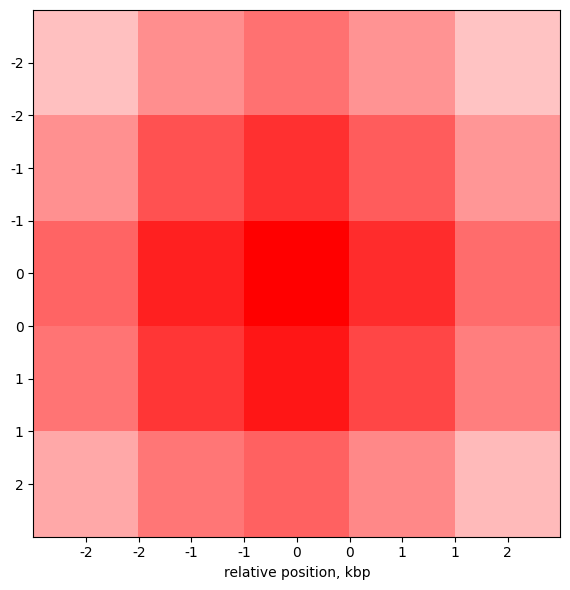

In [5]:
# ── Imports ──────────────────────────────────────────────────────────────────

# Standard
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Bio
import cooler
import cooltools
from coolpuppy.coolpup import pileup as cpp_pileup


# ── Global Values ──────────────────────────────────────────────────────────────────

# Window size NB this is also the minimal distance between CARs that will be considered
# If you consider too many low strength CARs that may be a problem
RESOLUTION  = 1000
FLANK       = 2_000 
ROOT        = "/home/nicolas/Documents/Workspace/nucleo/"


# ── Reading ──────────────────────────────────────────────────────────────────

clr = cooler.Cooler(
    ROOT +  "outputs/NUC/AD908_G2_mixed.mcool::/resolutions/1000"
)

df_CARs_NN = pd.read_parquet(
    ROOT + "notebooks/figures/article_1/df_CARs_NN.parquet"
)

view_df = pd.DataFrame({
    "chrom": clr.chromnames,
    "start": 0,
    "end": clr.chromsizes.values,
    "name": clr.chromnames
})

cvd = cooltools.expected_cis(
    clr=clr,
    view_df=view_df,
    clr_weight_name=None,
    smooth=True,
    aggregate_smoothed=False,
    nproc=8
)

pup = cpp_pileup(
    clr,
    df_CARs_NN,
    features_format="bedpe",
    flank=FLANK,
    view_df=view_df,
    expected_df=cvd,
    expected_value_col="count.avg.smoothed",
    clr_weight_name=None,
    nproc=8,
)


# ── Plot ──────────────────────────────────────────────────────────────────

fig, ax = plt.subplots(figsize=(6, 6))
mtx=pup.loc[0, 'data']
im=ax.imshow(
    np.log2((mtx)),
    cmap='bwr',
    vmin=-1,
    vmax=1,
interpolation='none')

ticks_pixels = np.linspace(0, FLANK*2//RESOLUTION,9)
ticks_kbp = ((ticks_pixels-ticks_pixels[-1]/2)*RESOLUTION//1000).astype(int)
ax.set(
    xticks=ticks_pixels,
    xticklabels=ticks_kbp,
    yticks=ticks_pixels,
    yticklabels=ticks_kbp,
    xlabel='relative position, kbp'
    )
        
fig.tight_layout()


# ── Print ──────────────────────────────────────────────────────────────────

display(cvd.head())
print(clr.bins().columns)

In [6]:
df_CARs_NN

,chrom1,start1,end1,CAR strength1,chrom2,start2,end2,CAR strength2
0,chrI,28578.0,28578.0,11.422373,chrI,30655.0,30655.0,11.147047
1,chrI,30655.0,30655.0,11.147047,chrI,51760.0,51760.0,67.978645
2,chrI,51760.0,51760.0,67.978645,chrI,65256.0,65256.0,21.715945
3,chrI,65256.0,65256.0,21.715945,chrI,80348.0,80348.0,60.766663
4,chrI,80348.0,80348.0,60.766663,chrI,95256.0,95256.0,35.290428
...,...,...,...,...,...,...,...,...
981,chrXVI,885906.0,885906.0,36.332651,chrXVI,893773.0,893773.0,20.768232
982,chrXVI,893773.0,893773.0,20.768232,chrXVI,909629.0,909629.0,14.050758
983,chrXVI,909629.0,909629.0,14.050758,chrXVI,916989.0,916989.0,32.328931
984,chrXVI,916989.0,916989.0,32.328931,chrXVI,930258.0,930258.0,20.321759


# Nucleosomes

In [ ]:
# ── Imports ──────────────────────────────────────────────────────────────────

# Standard
from pathlib import Path
import polars as pl


# ── DataFrames ──────────────────────────────────────────────────────────────────

# CARs
df_CARs_NN = pl.read_parquet("df_CARs_NN.parquet")

# Nucleosomes
root = Path("/home/nicolas/Documents/Workspace/nucleo/outputs/NUC/danpos.s2.xls")
df_NUCLEOSOMES = pl.read_csv(
    root,
    separator="\t"
)


# ── Analysis ──────────────────────────────────────────────────────────────────

# Adding New Columns
df_CARs_NUCLEO = df_CARs_NN.with_columns(
    pl.lit(None).alias("smt_pos"),
    pl.lit(None).alias("smt_value"),
    pl.lit(None).alias("fuzziness_score"),
    pl.lit(None).alias("NRLs")
)

# DataFrame Only With Positions for Filter
df_POS = df_NUCLEOSOMES.with_columns(
    pl.col("smt_pos").cast(pl.Float64)
)

# Adding a CAR Index
if "car_idx" not in df_CARs_NUCLEO.columns:
    df_CARs_NUCLEO = df_CARs_NUCLEO.with_row_index("car_idx")

# Filters
# joined a maintenant : car_idx, chrom1, start1, start2,
# + TOUTES les colonnes de df_NUCLEOSOMES (smt_pos, smt_value, fuzziness_score, etc.)
# → une ligne par (CAR, nucléosome) qui match
cars = df_CARs_NUCLEO.select(["car_idx", "chrom1", "start1", "start2"])
joined = cars.join_where(
    df_POS,
    pl.col("chr") == pl.col("chrom1"),
    pl.col("smt_pos") > pl.col("start1"),
    pl.col("smt_pos") < pl.col("start2"),
)


# ── Joining by CAR ──────────────────────────────────────────────

grouped = (
    joined
    .sort(["car_idx", "smt_pos"])
    .group_by("car_idx", maintain_order=True)
    .agg(
        pl.col("smt_pos"),
        pl.col("smt_value"),
        pl.col("fuzziness_score"),
        pl.col("smt_pos").diff().slice(1).alias("NRLs"),
    )
)

# Fusion finale : on remplace les colonnes placeholders (None)
df_CARs_NUCLEO = (
    df_CARs_NUCLEO
    .drop(["smt_pos", "smt_value", "fuzziness_score", "NRLs"])
    .join(grouped, on="car_idx", how="left")
)


# ── Median Values ──────────────────────────────────────────────

df_CARs_NUCLEO = df_CARs_NUCLEO.with_columns(
    pl.col("smt_pos").fill_null([]),
    pl.col("smt_value").fill_null([]),
    pl.col("fuzziness_score").fill_null([]),
    pl.col("NRLs").fill_null([]),
).with_columns(
    pl.col("NRLs").list.median().alias("NRLs_median"),
    pl.col("fuzziness_score").list.median().alias("fuzziness_median"),
    pl.col("smt_value").list.median().alias("smt_median"),
    pl.col("smt_value").list.len().alias("N_nuc"),
    (pl.col("smt_value").list.sum() / (pl.col("start2") - pl.col("start1"))).alias("smt_density"),
)


# ── Save ──────────────────────────────────────────────────
print(df_CARs_NUCLEO)
df_CARs_NUCLEO.write_parquet("df_CARs_NUCLEO.parquet")

shape: (986, 18)
┌─────────┬────────┬──────────┬──────────┬───┬──────────────────┬────────────┬───────┬─────────────┐
│ car_idx ┆ chrom1 ┆ start1   ┆ end1     ┆ … ┆ fuzziness_median ┆ smt_median ┆ N_nuc ┆ smt_density │
│ ---     ┆ ---    ┆ ---      ┆ ---      ┆   ┆ ---              ┆ ---        ┆ ---   ┆ ---         │
│ u32     ┆ str    ┆ f64      ┆ f64      ┆   ┆ f64              ┆ f64        ┆ u32   ┆ f64         │
╞═════════╪════════╪══════════╪══════════╪═══╪══════════════════╪════════════╪═══════╪═════════════╡
│ 0       ┆ chrI   ┆ 28578.0  ┆ 28578.0  ┆ … ┆ 54.672343        ┆ 480.0      ┆ 11    ┆ 22.840636   │
│ 1       ┆ chrI   ┆ 30655.0  ┆ 30655.0  ┆ … ┆ 52.414125        ┆ 21600.0    ┆ 121   ┆ 127.340441  │
│ 2       ┆ chrI   ┆ 51760.0  ┆ 51760.0  ┆ … ┆ 50.88625         ┆ 24640.0    ┆ 78    ┆ 150.349733  │
│ 3       ┆ chrI   ┆ 65256.0  ┆ 65256.0  ┆ … ┆ 54.413434        ┆ 19320.0    ┆ 86    ┆ 116.899019  │
│ 4       ┆ chrI   ┆ 80348.0  ┆ 80348.0  ┆ … ┆ 52.298347        ┆ 27040.0 

# Analysing by Categories

shape: (986, 18)
┌─────────┬────────┬──────────┬──────────┬───┬──────────────────┬────────────┬───────┬─────────────┐
│ car_idx ┆ chrom1 ┆ start1   ┆ end1     ┆ … ┆ fuzziness_median ┆ smt_median ┆ N_nuc ┆ smt_density │
│ ---     ┆ ---    ┆ ---      ┆ ---      ┆   ┆ ---              ┆ ---        ┆ ---   ┆ ---         │
│ u32     ┆ str    ┆ f64      ┆ f64      ┆   ┆ f64              ┆ f64        ┆ u32   ┆ f64         │
╞═════════╪════════╪══════════╪══════════╪═══╪══════════════════╪════════════╪═══════╪═════════════╡
│ 0       ┆ chrI   ┆ 28578.0  ┆ 28578.0  ┆ … ┆ 54.672343        ┆ 480.0      ┆ 11    ┆ 22.840636   │
│ 1       ┆ chrI   ┆ 30655.0  ┆ 30655.0  ┆ … ┆ 52.414125        ┆ 21600.0    ┆ 121   ┆ 127.340441  │
│ 2       ┆ chrI   ┆ 51760.0  ┆ 51760.0  ┆ … ┆ 50.88625         ┆ 24640.0    ┆ 78    ┆ 150.349733  │
│ 3       ┆ chrI   ┆ 65256.0  ┆ 65256.0  ┆ … ┆ 54.413434        ┆ 19320.0    ┆ 86    ┆ 116.899019  │
│ 4       ┆ chrI   ┆ 80348.0  ┆ 80348.0  ┆ … ┆ 52.298347        ┆ 27040.0 

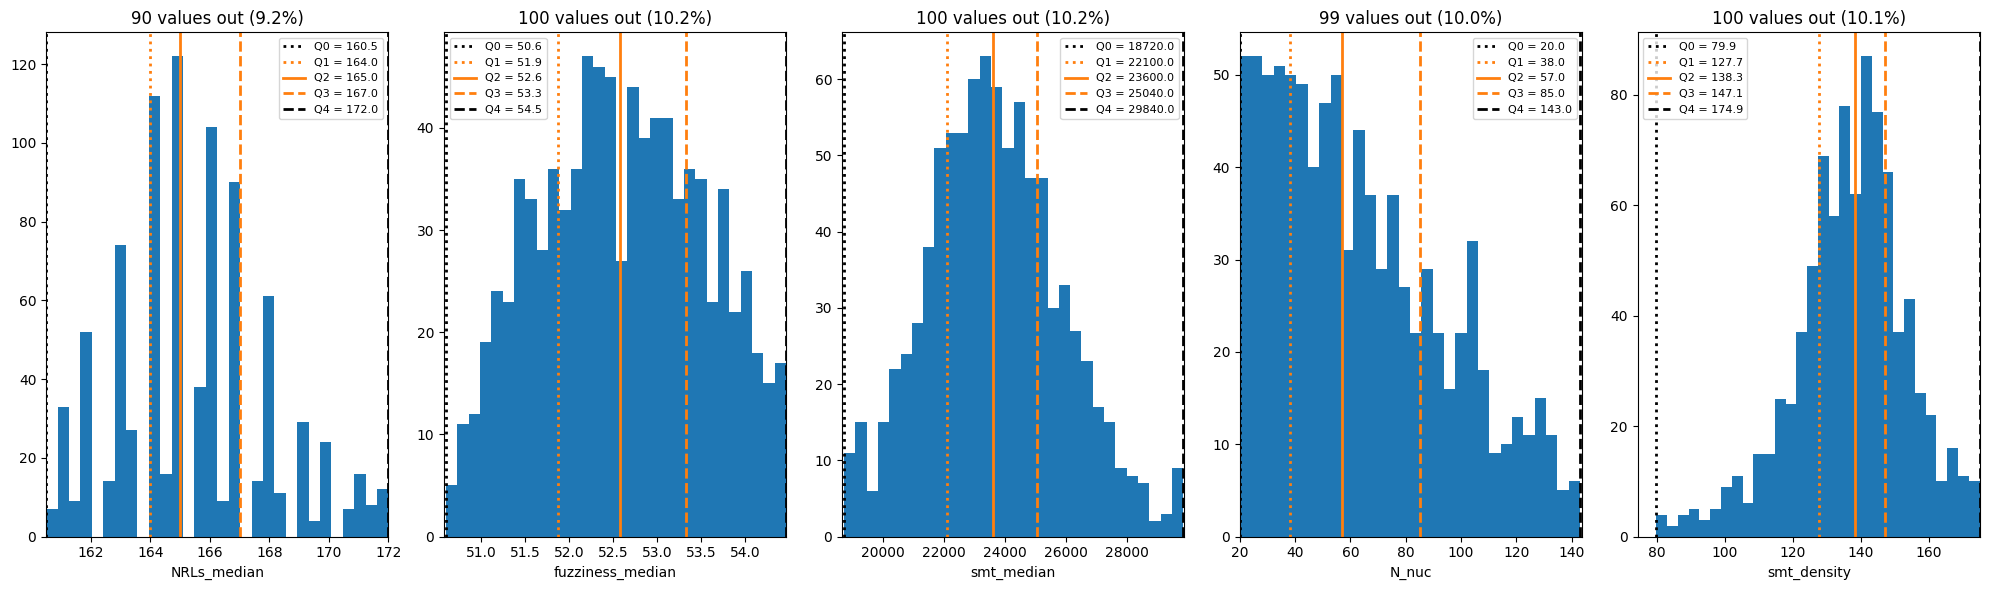

In [48]:
# ── Imports ──────────────────────────────────────────────────────────────────

# Standard
import numpy as np
import matplotlib.pyplot as plt
import polars as pl


# ── DataFrames ──────────────────────────────────────────────────────────────────

# CARs
df_CARs_NUCLEO = pl.read_parquet("df_CARs_NUCLEO.parquet")
print(df_CARs_NUCLEO)



# ── Prelimenary Analysis ──────────────────────────────────────────────────────

fig, axes = plt.subplots(figsize=(20, 6), ncols=5, nrows=1)

columns     = ["NRLs_median", "fuzziness_median", "smt_median", "N_nuc", "smt_density"]
quartiles   = []

for ax, col in zip(axes, columns):

    # Suppression des NaN / inf
    values = df_CARs_NUCLEO[col].to_numpy()
    values = values[np.isfinite(values)]

    # Conservation des 90 % centraux
    vmin, vmax = np.percentile(values, [5, 95])
    values_plot = values[(values >= vmin) & (values <= vmax)]

    n_removed = len(values) - len(values_plot)

    # Quartiles
    q25, q50, q75 = np.percentile(values_plot, [25, 50, 75])
    q0, q100 = np.min(values_plot), np.max(values_plot)
    quartiles.append({
        "value": col,
        "q0": q0,
        "q25": q25,
        "q50": q50,
        "q75": q75,
        "q100": q100,
    })

    # Histogramme
    ax.hist(values_plot, bins=30)
    ax.set_xlim(vmin, vmax)

    # Quartiles
    ax.axvline(q0, color="black", linestyle=":", linewidth=2, label=f"Q0 = {q0:.1f}")
    ax.axvline(q25, color="tab:orange", linestyle=":", linewidth=2, label=f"Q1 = {q25:.1f}")
    ax.axvline(q50, color="tab:orange", linestyle="-", linewidth=2, label=f"Q2 = {q50:.1f}")
    ax.axvline(q75, color="tab:orange", linestyle="--", linewidth=2, label=f"Q3 = {q75:.1f}")
    ax.axvline(q100, color="black", linestyle="--", linewidth=2, label=f"Q4 = {q100:.1f}")

    # P
    ax.set_xlabel(col)
    ax.set_title(f"{n_removed} values out ({100*n_removed/len(values):.1f}%)")
    ax.legend(fontsize=8)

quartiles = pl.DataFrame(quartiles)
plt.tight_layout()
plt.show()

In [49]:
print(quartiles)

shape: (5, 6)
┌──────────────────┬───────────┬────────────┬────────────┬────────────┬────────────┐
│ value            ┆ q0        ┆ q25        ┆ q50        ┆ q75        ┆ q100       │
│ ---              ┆ ---       ┆ ---        ┆ ---        ┆ ---        ┆ ---        │
│ str              ┆ f64       ┆ f64        ┆ f64        ┆ f64        ┆ f64        │
╞══════════════════╪═══════════╪════════════╪════════════╪════════════╪════════════╡
│ NRLs_median      ┆ 160.5     ┆ 164.0      ┆ 165.0      ┆ 167.0      ┆ 172.0      │
│ fuzziness_median ┆ 50.604806 ┆ 51.874667  ┆ 52.578119  ┆ 53.329526  ┆ 54.466983  │
│ smt_median       ┆ 18720.0   ┆ 22100.0    ┆ 23600.0    ┆ 25040.0    ┆ 29840.0    │
│ N_nuc            ┆ 20.0      ┆ 38.0       ┆ 57.0       ┆ 85.0       ┆ 143.0      │
│ smt_density      ┆ 79.850875 ┆ 127.684024 ┆ 138.268401 ┆ 147.104161 ┆ 174.856767 │
└──────────────────┴───────────┴────────────┴────────────┴────────────┴────────────┘


# HiC Map

/tmp/ipykernel_110923/3395831196.py:4: RuntimeWarning: divide by zero encountered in log2
  np.log2(mtx_2),


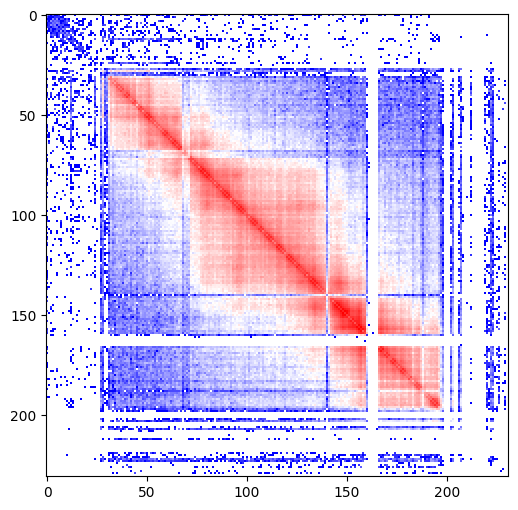

In [5]:
fig, ax = plt.subplots(figsize=(6, 6))
mtx_2=clr.matrix(balance=False).fetch("chrI")
im=ax.imshow(
    np.log2(mtx_2),
    cmap='bwr',
    # vmin=-1,
    # vmax=1,
interpolation='none')

# .